In [1]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

In [3]:
#loading data

df = pd.read_csv('clean_final.csv')   #clean_final.csv used for model training

In [4]:
df = df.drop(columns=['Unnamed: 0'])

In [5]:
#seperating X and y

X = df.drop('Price', axis=1)
y = df['Price'].apply(np.log)  #log transformation applied

In [6]:
#splitting dataframe
split = int(0.8 * len(X))
X_train = X[0:split]
X_test  = X[split:]
y_train = y[0:split]
y_test  = y[split:]

# Converting to NumPy arrays
X_train = X_train.values.astype(np.float64) 
X_test  = X_test.values.astype(np.float64)
y_train = y_train.values.astype(np.float64)
y_test  = y_test.values.astype(np.float64)

In [7]:
m = X_train.shape[0]   # number of rows
n = X_train.shape[1]   # number of features
m_test = X_test.shape[0]

In [8]:
#feature scaling
means = np.mean(X_train, axis=0) #mean calculation

stds = np.std(X_train, axis=0)    #standard deviation
stds[stds == 0] = 1

X_train_scaled = (X_train - means) / stds
X_test_scaled  = (X_test - means) / stds

In [12]:
#gradient descent... took assistance  of AI a bit

weights = np.zeros(n)
bias    = 0.0
 
learning_rate = 0.01
iterations    = 1000
 
cost_history      = []
iteration_history = []

start_time = time.time()
 
for iteration in range(iterations):
 
    # Forward pass
    predictions = np.dot(X_train_scaled, weights) + bias
 
    # cost calculation
    errors = predictions - y_train
    cost = np.sum(errors ** 2) / (2 * m)
 
    # Computing gradients
    dw = np.dot(X_train_scaled.T, errors) / m
    db = np.sum(errors) / m
 
    # Updating weights and bias
    weights = weights - learning_rate * dw
    bias    = bias - learning_rate * db
 
    # Storing cost every 100 iterations
    if iteration % 100 == 0:
        cost_history.append(cost)
        iteration_history.append(iteration)
        print(f"  Iteration {iteration:4d} | Cost: {cost:.6f}")
 
convergence_time = time.time() - start_time
print(f"\nConvergence time: {convergence_time:.4f} seconds")

  Iteration    0 | Cost: 95.860123
  Iteration  100 | Cost: 12.869699
  Iteration  200 | Cost: 1.756860
  Iteration  300 | Cost: 0.267148
  Iteration  400 | Cost: 0.067060
  Iteration  500 | Cost: 0.039975
  Iteration  600 | Cost: 0.036186
  Iteration  700 | Cost: 0.035583
  Iteration  800 | Cost: 0.035444
  Iteration  900 | Cost: 0.035388

Convergence time: 0.5906 seconds


In [13]:
#evaluation
test_predictions = np.dot(X_test_scaled, weights) + bias

#R2 score
y_mean = np.mean(y_test)
 
tss = np.sum((y_test - y_mean) ** 2)
rss = np.sum((y_test - test_predictions) ** 2)
r2_score = 1 - (rss / tss)
print(f"\nR2 Score : {r2_score:.4f}")

#log predictions to actual price for mae and rmse
y_test_actual = np.exp(y_test)
y_pred_actual = np.exp(test_predictions)

#rmse
mse = np.mean((y_test_actual - y_pred_actual) ** 2)
rmse = np.sqrt(mse)
print(f"RMSE     : ${rmse:,.0f}")

#mae
mae = np.mean(np.abs(y_test_actual - y_pred_actual))
print(f"MAE      : ${mae:,.0f}")


R2 Score : 0.6999
RMSE     : $381,355
MAE      : $221,451


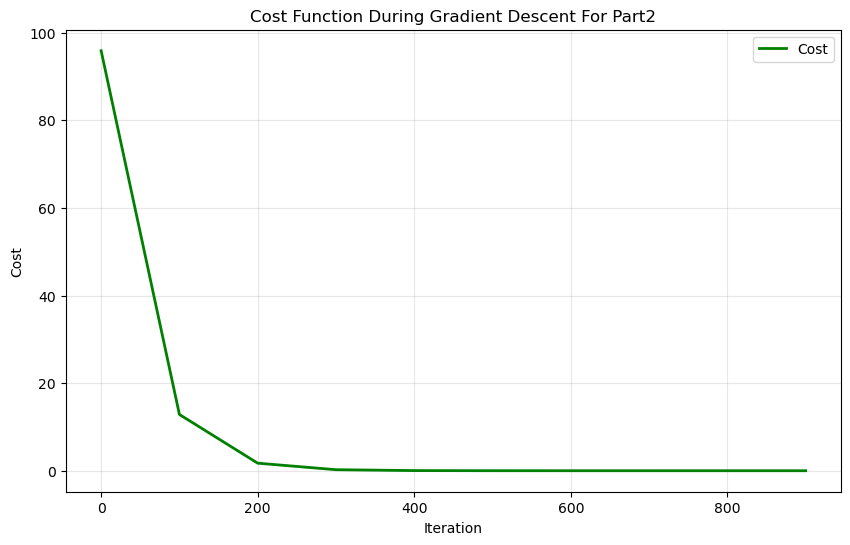

In [17]:
#plotting cost curve

plt.figure(figsize=(10, 6))
plt.plot(iteration_history, cost_history, 'g-', linewidth=2, label='Cost')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost Function During Gradient Descent For Part2')
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig("Curve_Part2.png")
plt.show()
